### IMPORT REQUIREMENTS

In [1]:
import time
import sys
import cv2
import os
import yaml
import torch
import numpy as np
from PIL import Image
from pathlib import Path
import tensorrt as trt
from ultralytics import YOLO
import matplotlib.pyplot as plt
from torchvision import transforms
import torchvision.transforms as transforms
from cuda.bindings import runtime as cudart
import shutil
from zipfile import ZipFile

# PHASE 1

# Yolo .pt Model


### LOAD .pt MODEL & IMAGE FOLDER


In [2]:
# Path of Your Project  Dir.
project_dir=os.getcwd()
print(project_dir)

/workspace/Classification_Model_Evaluation


### Download YOLO Model

In [3]:
# Download yolo Model
model_name = "yolo26n-cls.pt"
model = YOLO(model_name)

m_load=os.path.join(os.getcwd(),model_name)

# Moveing Model In To Model Directory 
directory_path=os.path.join(project_dir,"Classification _Models/")
full_path_model=os.path.join(directory_path,model_name)

shutil.move(m_load,full_path_model)

'/workspace/Classification_Model_Evaluation/Classification _Models/yolo26n-cls.pt'

### **Download Sample Images From Below Given Link or You Can Use Yours As Well**
##### https://drive.google.com/drive/folders/1MuNF6ytZHTcroBpnlwIUoWkaxl0oTTOS
### If you using Docker Container Extract Images Into Your Working Directory

In [4]:
# # Change Zip File Path According To Your Zip Path
# Downloaded_dir="/home/easemyai/Downloads/"
# zip_name="Images-20260709T083605Z-3-001.zip"

# images_path=os.path.join(Downloaded_dir,zip_name)
# with ZipFile(images_path, 'r') as zObject:
#     zObject.extractall(path=project_dir)

#### YOLO classification models are trained on the ImageNet dataset. During inference, Ultralytics automatically maps the predicted class index to its corresponding ImageNet class name using the provided dataset configuration. So for 1st phase that not require but for 2nd and 3rd phase that requires to you

#### The ImageNet label configuration is available here:

https://github.com/ultralytics/ultralytics/blob/main/ultralytics/cfg/datasets/ImageNet.yaml
### If you using Docker Container Shift Downloaded YAML file into cls-yaml Foler present in your Working Directory

In [5]:
# # Load yaml file into your cls-yaml directory
# def find(name, path):
#     for root, dirs, files in os.walk(path):
#         if name in files:
#             return os.path.join(root, name)

# # Update This Downloaded Path According To Your Path
# Downloaded_dir="/home/easemyai/Downloads/"

# YAML_name="ImageNet.yaml"

# full_path_yaml=os.path.join(project_dir,"cls-yaml")
# path_yaml_file=find(YAML_name,Downloaded_dir)
# shutil.move(path_yaml_file,full_path_yaml)

In [6]:
# Accessing Model, Images, Yaml from your Project Dir.
model_pt = "Classification _Models/yolo26n-cls.pt"
images = "Images"
imagenet="cls-yaml/ImageNet.yaml"

model_path_pt=os.path.join(os.getcwd(),model_pt)
image_folder=os.path.join(os.getcwd(),images)
imagenet_yaml=os.path.join(os.getcwd(),imagenet)
# print(os.path.join(os.getcwd()))
print("Model Path: ",model_path_pt)
print("Image Folder Path: ", image_folder)
print("Imagenet YAML Path: ",imagenet_yaml)
# Image Size
img_size = 224

Model Path:  /workspace/Classification_Model_Evaluation/Classification _Models/yolo26n-cls.pt
Image Folder Path:  /workspace/Classification_Model_Evaluation/Images
Imagenet YAML Path:  /workspace/Classification_Model_Evaluation/cls-yaml/ImageNet.yaml


### LOAD MODEL TO GPU

In [7]:
# Load Model Into GPU

device = torch.device("cuda")

# device="cuda"

model = YOLO(model_path_pt)

model.to(device)

YOLO(
  (model): ClassificationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=1e-05, momentu

### PREPROCESS

In [8]:
# Yolo classification models are trained with an input image size of 224 × 224.

# Although the original image can have any resolution, it will be resized to 224 × 224 during preprocessing before being passed to the model.
# The preprocessing pipeline includes operations such as:

# - Resize
# - ToTensor
# - Normalize

# Batch creation is important because neural networks expect the input in the form:

# Batch Size × Channels × Height × Width

# (B, C, H, W)

# instead of processing one image at a time.


def preprocess(folder_path, imgsz=224):


    transform = transforms.Compose([
        transforms.Resize((imgsz, imgsz)),
        transforms.ToTensor()
    ])
    
    # Sorting Images according to there orders
    image_paths = sorted([
        os.path.join(folder_path, file)
        for file in os.listdir(folder_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ])

    image_tensors = []

    print("=" * 60)
    print("PREPROCESS")
    print("=" * 60)

    # Perform Preprocess on Image (RGB color conversion, resize, normalisation) 

    for path in image_paths:

        image = Image.open(path).convert("RGB")

        tensor = transform(image)

        image_tensors.append(tensor)

        # print("Loaded :", os.path.basename(path))

        
    # Creating Stack of Image (batch or group of image present in your image folder)
    batch = torch.stack(image_tensors).to(device)

    print("\nBatch Shape :", batch.shape)

    print()

    return batch, image_paths

### INFERENCE

In [9]:
# During this stage, the preprocessed batch is passed to the model.

# The GPU performs the forward pass and generates prediction for every image in the batch.


def inference(model, batch):
    print("=" * 60)
    print("INFERENCE")
    print("=" * 60)
    torch.cuda.synchronize()

    start = time.perf_counter()

    results = model(batch, verbose=False)

    torch.cuda.synchronize()

    end = time.perf_counter()

    inference_time = (end - start)

    batch_size = batch.shape[0]

    
    print(f"Batch Size           : {batch_size}")
    print(f"Batch Inference Time : {inference_time:.3f} s")
    print(f"Per Image Latency    : {inference_time / batch_size:.3f} s")

    print()

    return results

### POSTPROCESS

In [10]:
# This stage converts the raw model outputs into human-readable predictions.

# Operations include:
# - Extract prediction score (confidence)
# - Find the class with the highest confidence
# - Display predicted class name
# - Display confidence score

def postprocess(results, image_paths):

    print("=" * 60)
    print("PREDICTIONS")
    print("=" * 60)

    for image_path, result in zip(image_paths, results):

        probs = result.probs

        class_id = probs.top1

        confidence = probs.top1conf.item()

        class_name = result.names[class_id]

        print(f"\nImage      : {os.path.basename(image_path)}")
        # img = Image.open(image_path).convert("RGB")
        # plt.imshow(img)
        print(f"Prediction : {class_name}")
        print(f"Confidence : {confidence:.4f}")

### Main

In [11]:
def main():
    # Calling All Functions 
    batch, image_paths = preprocess(image_folder,img_size)

    results = inference(model,batch)

    postprocess(results,image_paths)

if __name__ == "__main__":
    main()

PREPROCESS

Batch Shape : torch.Size([5, 3, 224, 224])

INFERENCE
Batch Size           : 5
Batch Inference Time : 0.569 s
Per Image Latency    : 0.114 s

PREDICTIONS

Image      : Cat_November_2010-1a.jpg.webp
Prediction : tiger_cat
Confidence : 0.3949

Image      : images.jpeg
Prediction : Saluki
Confidence : 0.7916

Image      : images1.jpeg
Prediction : tiger
Confidence : 0.7551

Image      : istockphoto-1189925691-612x612.jpg
Prediction : passenger_car
Confidence : 0.7372

Image      : tigermain.jpg
Prediction : tiger
Confidence : 0.9407


########################################################################################################################### 

###########################################################################################################################################

###########################################################################################################################################

# Phase 2

## ONNX

### Go To INSTALLATION.md File To See Steps Of Installation For Phase 2

In [12]:
pip install onnxruntime-gpu --break-system-packages

Note: you may need to restart the kernel to use updated packages.


### EXPORT TO ONNX

In [13]:
# Genarating onnx model using yolo .pt model file and load into cuda GPU 
# This Model automatically export in your Models dir. 
# batch = number of inputs can handle by model at once
# dynamic = Model support less 16 inputs as well but not greater than 16 batch of images
import onnxruntime as ort
model.export(format="onnx",imgsz=224,batch=16,dynamic=True,device="cuda")

print("\nONNX export completed successfully.")

Ultralytics 8.4.75 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA RTX A4000, 15974MiB)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/workspace/Classification_Model_Evaluation/Classification _Models/yolo26n-cls.pt' with input shape (16, 3, 224, 224) BCHW and output shape(s) (16, 1000) (5.5 MB)
requirements: Ultralytics requirement ['onnxslim>=0.1.82'] not found, attempting AutoUpdate...

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [onnxslim]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [onnxslim]


requirements: AutoUpdate success ✅ 1.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.22.0 opset 18...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.9s, saved as '/workspace/Classification_Model_Evaluation/Classification _Models/yolo26n-cls.onnx' (10.8 MB)

Export complet

### LOAD ONNX MODEL PATH

In [14]:
onnx_model = os.path.join(os.getcwd(),"Classification _Models/yolo26n-cls.onnx")
print(onnx_model)

/workspace/Classification_Model_Evaluation/Classification _Models/yolo26n-cls.onnx


In [15]:
# Loading Your Session into GPU
# If session by default load into CPUExecutionProvider then you CUDAExecutionProvider not in work for execution.
# So follow the steps present in the INSTALLATION.md to solve this problem 

opts = ort.SessionOptions()

# Force ONNX Runtime to raise an exception if an op cannot run on the requested EP

opts.add_session_config_entry("session.required_cuda_compute_capability", "0") 

# This configuration forces strict provider matching
session = ort.InferenceSession(onnx_model, providers=['CUDAExecutionProvider'], sess_options=opts)

input_name = session.get_inputs()[0].name

print("Strict session created successfully on GPU!")

# To see available and session providers which we can use for execution
print("Available Providers:", ort.get_available_providers())
print("Session Providers:", session.get_providers())

Strict session created successfully on GPU!
Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Session Providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']


### PREPROCESS

In [16]:
# Preprocess Phase 
def preprocess_images_onnx(folder_path, imgsz=224):

    transform = transforms.Compose([
        transforms.Resize((imgsz, imgsz)),
        transforms.ToTensor()
    ])

    image_files = sorted([
        file
        for file in os.listdir(folder_path)
        if file.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp", ".webp")
        )
    ])

    image_list = []

    print("=" * 60)
    print("PREPROCESS")
    print("=" * 60)

    for file in image_files:

        image_path = os.path.join(folder_path, file)

        image = Image.open(image_path).convert("RGB")

        tensor = transform(image)

        image_list.append(tensor)

    batch_tensor = torch.stack(image_list)

    batch_numpy = batch_tensor.numpy().astype(np.float32)

    print("Number of Images :", len(image_files))
    print("Batch Shape      :", batch_numpy.shape)
    print("Input dtype      :", batch_numpy.dtype)
    print()

    return batch_numpy, image_files

### INFERENCE

In [17]:
# Inference Phase
def inference_onnx(session, batch_numpy):

    input_name = session.get_inputs()[0].name

    start = time.perf_counter()

    outputs = session.run(
        None,
        {input_name: batch_numpy}
    )

    end = time.perf_counter()

    # inference_time = (end - start) * 1000
    inference_time = (end - start)

    batch_size = batch_numpy.shape[0]

    print("=" * 60)
    print("ONNX RUNTIME PERFORMANCE")
    print("=" * 60)
    print(f"Batch Size           : {batch_size}")
    print(f"Batch Inference Time : {inference_time:.3f}")
    print(f"Per Image Latency    : {inference_time / batch_size:.3f}")
    print()

    return outputs[0], inference_time

### POSTPROCESS

In [18]:
# Postprocess Phase

def postprocess_onnx(predictions,image_files,folder_path,imagenet_yaml):

    print("=" * 60)
    print("POSTPROCESS")
    print("=" * 60)

    with open(imagenet_yaml, "r") as f:
        data = yaml.safe_load(f)

    class_names = data["names"]

    class_ids = np.argmax(predictions, axis=1)
    scores = np.max(predictions, axis=1)

    fig, axes = plt.subplots(
        1,
        len(image_files),
        figsize=(5 * len(image_files), 5)
    )

    if len(image_files) == 1:
        axes = [axes]

    for i, ax in enumerate(axes):

        image = Image.open(
            os.path.join(folder_path, image_files[i])
        ).convert("RGB")

        class_id = int(class_ids[i])

        class_name = class_names.get(
            class_id,
            class_names.get(str(class_id), "Unknown")
        )

        # print(f"\nImage      : {image_files[i]}")
        # print(f"Prediction : {class_name}")
        # print(f"Confidence : {scores[i]:.4f}")

        ax.imshow(image)

        ax.set_title(
            f"{class_name}\n"
            f"{scores[i]:.4f}")

        ax.axis("off")

    plt.tight_layout()
    plt.show()

### MAIN

PREPROCESS
Number of Images : 5
Batch Shape      : (5, 3, 224, 224)
Input dtype      : float32

ONNX RUNTIME PERFORMANCE
Batch Size           : 5
Batch Inference Time : 0.157
Per Image Latency    : 0.031

POSTPROCESS


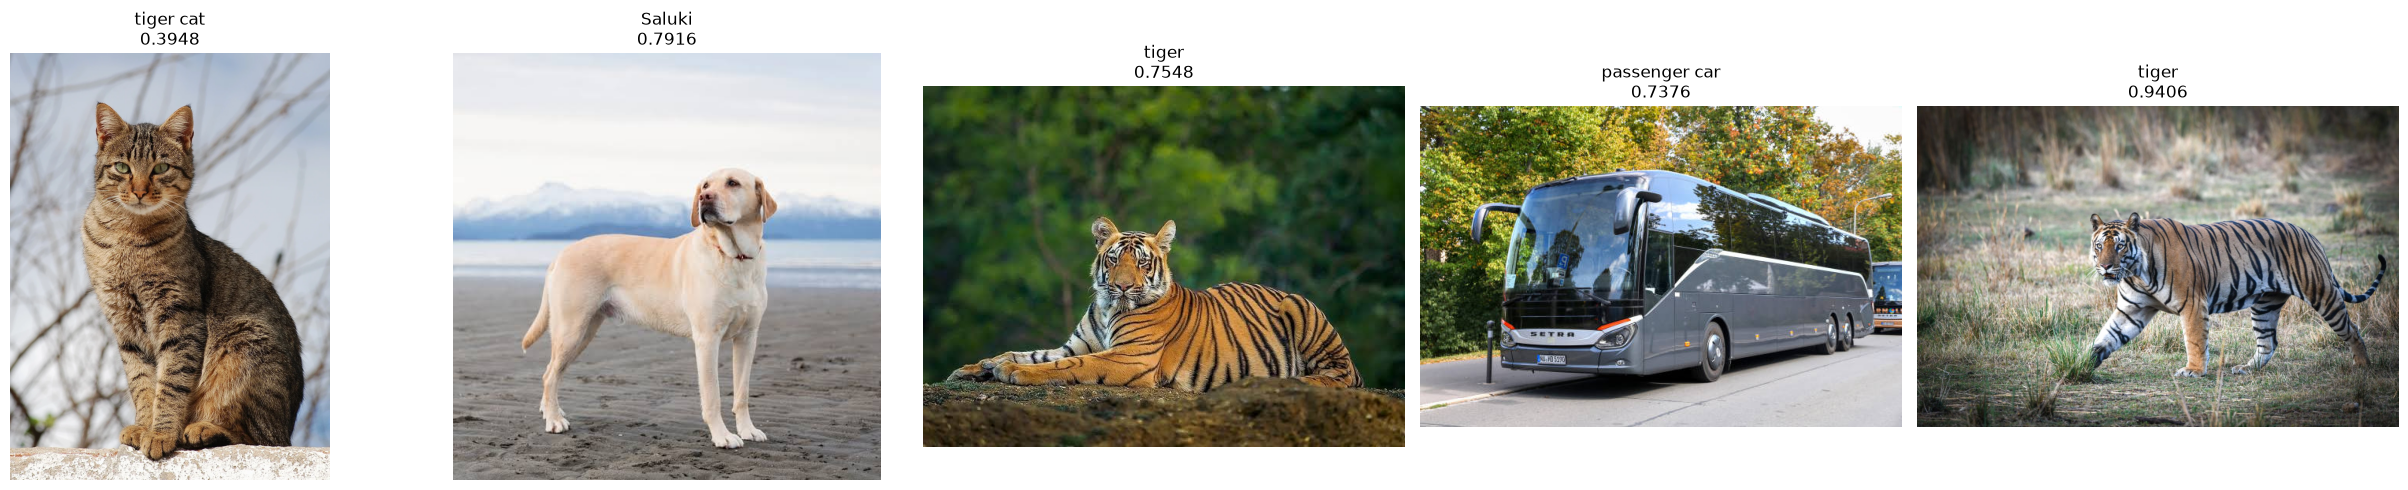

In [19]:
def main():
    
    batch_numpy, image_files = preprocess_images_onnx(image_folder,img_size)
    
    predictions, inference_time = inference_onnx(session,batch_numpy)
    
    postprocess_onnx(predictions,image_files,image_folder,imagenet_yaml)

if __name__ == "__main__":
    main()

# Phase 3

## TensorRT Engine Model

##### Go To Your Terminal Inside Your Project Directory And Execute This Following 2 Commands
##### If Your using Docker Container then use following command to open container in another terminal
##### 1)
###### docker exec -it container_name bash

##### 2)
###### cd Classification_Model_Evaluation/'Classification _Models'

##### 2)
###### trtexec \
###### --onnx=yolo26n-cls.onnx \
###### --minShapes=images:1x3x224x224 \
###### --optShapes=images:4x3x224x224 \
###### --maxShapes=images:16x3x224x224 \
###### --saveEngine=yolo26n-cls.engine

### LOAD ENGINE PATH

In [26]:
engine_model=os.path.join(os.getcwd(),"Classification _Models/yolo26n-cls.engine")
print(engine_model)

/workspace/Classification_Model_Evaluation/Classification _Models/yolo26n-cls.engine


### Check Error Function 

In [27]:
# Check Function for Checking error logs
def check_cuda(err):

    if isinstance(err,tuple):
        err=err[0]

    if err != cudart.cudaError_t.cudaSuccess:
        raise RuntimeError(f"CUDA Error : {err}")

### PREPROCESS

In [28]:
# Preprocess Phase
def preprocess_images_engine(folder_path, imgsz=224):

    transform = transforms.Compose([
        transforms.Resize((imgsz, imgsz)),
        transforms.ToTensor()
    ])

    image_files = sorted(os.listdir(folder_path))

    images = []

    for file in image_files:

        img = Image.open(os.path.join(folder_path, file)).convert("RGB")

        tensor = transform(img)

        images.append(tensor)

    batch = np.stack([img.numpy() for img in images]).astype(np.float32)

    print("=" * 60)
    print("PREPROCESS")
    print("=" * 60)

    print("Batch Shape :", batch.shape)

    return batch, image_files

### INFERENCE

In [29]:

def inference_engine(batch_numpy,engine_model):


    TRT_LOGGER = trt.Logger(trt.Logger.WARNING)

    with open(engine_model, "rb") as f:
        runtime = trt.Runtime(TRT_LOGGER)
        engine = runtime.deserialize_cuda_engine(f.read())

    context = engine.create_execution_context()
    
    input_name = engine.get_tensor_name(0)
    
    output_name = engine.get_tensor_name(1)
    

    context.set_input_shape(input_name, batch_numpy.shape)

    output_shape = tuple(context.get_tensor_shape(output_name))

    host_input = np.ascontiguousarray(batch_numpy)
    host_output = np.empty(output_shape, dtype=np.float32)

    # Allocate GPU memory
    err, d_input = cudart.cudaMalloc(host_input.nbytes)
    check_cuda(err)

    err, d_output = cudart.cudaMalloc(host_output.nbytes)
    check_cuda(err)

    # Create CUDA stream
    err, stream = cudart.cudaStreamCreate()
    check_cuda(err)


    start = time.perf_counter()

    # Host -> Device
    check_cuda(
        cudart.cudaMemcpyAsync(
            d_input,
            host_input.ctypes.data,
            host_input.nbytes,
            cudart.cudaMemcpyKind.cudaMemcpyHostToDevice,
            stream,
        )
    )

    # Bind tensors
    context.set_tensor_address(input_name, int(d_input))
    context.set_tensor_address(output_name, int(d_output))

    # TensorRT inference
    context.execute_async_v3(stream)

    # Device -> Host
    check_cuda(
        cudart.cudaMemcpyAsync(
            host_output.ctypes.data,
            d_output,
            host_output.nbytes,
            cudart.cudaMemcpyKind.cudaMemcpyDeviceToHost,
            stream,
        )
    )

    # Wait for GPU
    check_cuda(cudart.cudaStreamSynchronize(stream))

    # -----------------------------
    # End Timer
    # -----------------------------
    end = time.perf_counter()

    # inference_time = (end - start) * 1000
    inference_time = (end - start)

    batch_size = batch_numpy.shape[0]

    print("\n" + "=" * 60)
    print("TENSORRT PERFORMANCE")
    print("=" * 60)
    print(f"Batch Size           : {batch_size}")
    print(f"Batch Inference Time : {inference_time:.3f} ")
    print(f"Per Image Latency    : {inference_time/batch_size:.3f} ")


    # Cleanup
    cudart.cudaFree(d_input)
    cudart.cudaFree(d_output)
    cudart.cudaStreamDestroy(stream)

    return host_output

### POSTPROCESS

In [30]:
def postprocess_engine(predictions,image_files,folder_path,imagenet_yaml):

    with open(imagenet_yaml, "r") as f:

        data = yaml.safe_load(f)

    class_names = data["names"]

    class_ids = np.argmax(predictions, axis=1)

    scores = np.max(predictions, axis=1)

    fig, axes = plt.subplots(
        1,
        len(image_files),
        figsize=(5 * len(image_files), 5)
    )

    if len(image_files) == 1:

        axes = [axes]

    for i, ax in enumerate(axes):

        img = Image.open(
            os.path.join(folder_path, image_files[i])
        ).convert("RGB")

        idx = int(class_ids[i])

        class_name = class_names.get(
            idx,
            class_names.get(str(idx), "Unknown")
        )

        ax.imshow(img)

        ax.set_title(
            f"{class_name}\n{scores[i]:.4f}"
        )

        ax.axis("off")

    plt.tight_layout()

    plt.show()

### MAIN

PREPROCESS
Batch Shape : (5, 3, 224, 224)

TENSORRT PERFORMANCE
Batch Size           : 5
Batch Inference Time : 0.053 
Per Image Latency    : 0.011 


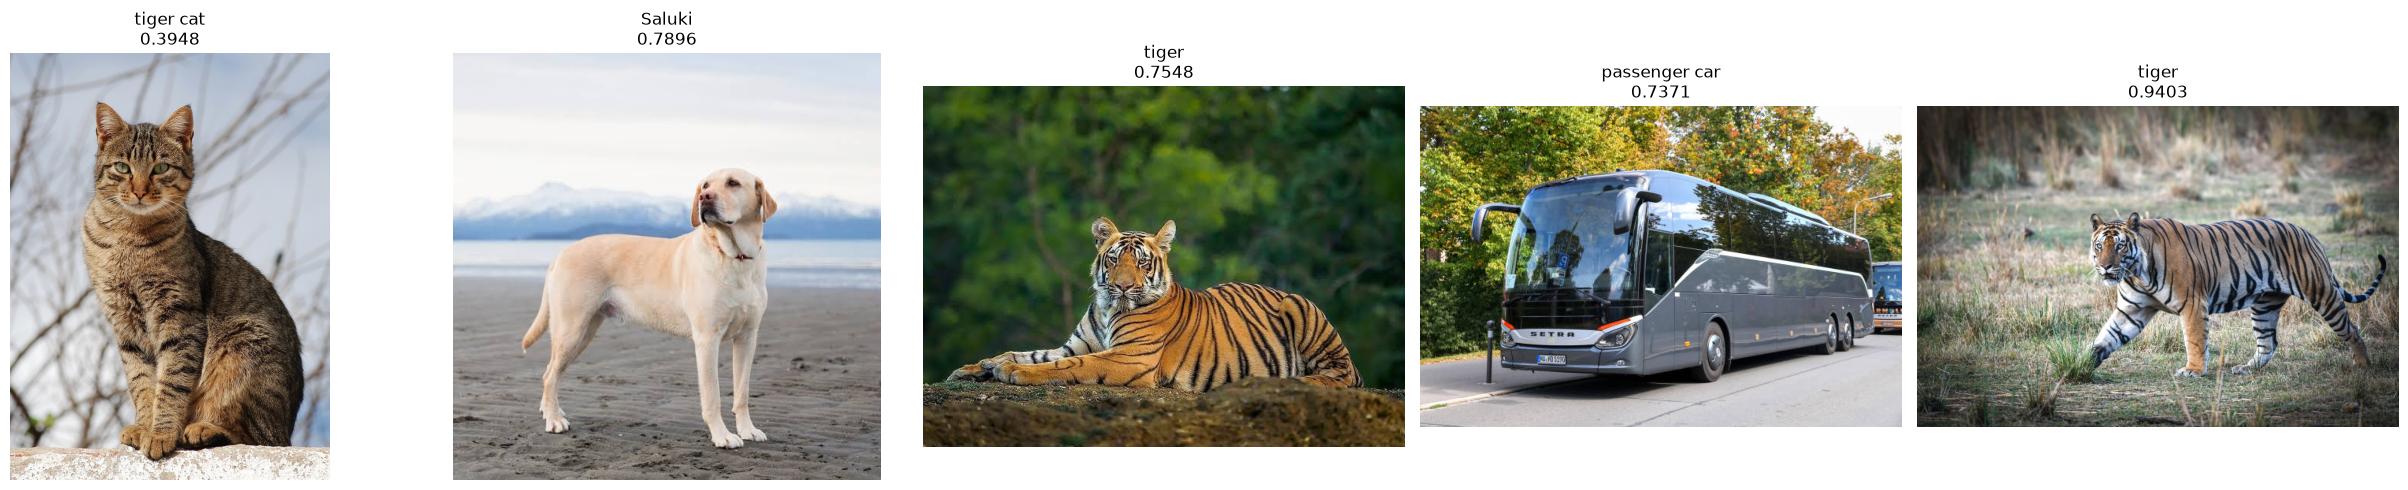

In [31]:
def main():
    batch_numpy, image_files = preprocess_images_engine(image_folder)

    predictions = inference_engine(batch_numpy,engine_model)

    postprocess_engine(predictions,image_files,image_folder,imagenet_yaml)

if __name__=="__main__":
    main()